# Florida population forecast walkthrough

A step-by-step run of `population_forecast.py`. It uses the same models as
`../charlotte/charlotte_walkthrough.ipynb` (damped-trend ETS and
ARIMA(1,1,1), chosen by rolling backtest), applied to Florida's five largest
cities.

Population comes from the Florida EDR municipal estimates in
`data/FLmupops.xlsx`, which cover every incorporated Florida city from 1979.
The file is included, so the notebook runs offline with no API key.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sources.edr_population import build_panel, city_series, list_cities, filter_florida, clean_city_name
from population_forecast import run_city, TARGET_CITIES, MIN_OBS, HORIZON

%matplotlib inline

## 1. Load the population panel

`build_panel` reads every year sheet of the EDR workbook into one long table:
year, place_id, city, county, population. `filter_florida` does nothing here,
since the data is already Florida-only; it is kept so the code also works
with the Census ACS1 loader in `../model_benchmark/core/census.py`.

In [2]:
panel = build_panel()
fl_panel = filter_florida(panel)
print(f"{fl_panel['city'].nunique()} Florida municipalities, "
      f"{fl_panel['year'].min()}-{fl_panel['year'].max()}")

424 Florida municipalities, 1979-2025


## 2. Pick out the target cities

The five cities are defined in `sources/cities.py`. `list_cities` lists every
municipality in the workbook, sorted by latest population.

In [3]:
print("Target cities:", TARGET_CITIES)

all_cities = list_cities(fl_panel)
targets = all_cities[all_cities["city"].isin(TARGET_CITIES)]
targets.assign(population=targets["population"].map("{:,.0f}".format))

Target cities: ('Jacksonville', 'Miami', 'Tampa', 'Orlando', 'St. Petersburg')


,city,population
place_id,,
1235000,Jacksonville,"1,032,601"
1245000,Miami,"478,799"
1271000,Tampa,"412,684"
1253000,Orlando,"340,681"
1263000,St. Petersburg,"266,153"


## 3. Backtest and forecast each city

For each city, `run_city` backtests ETS and ARIMA 5 years ahead over rolling
windows, keeps the model with the lower average error, and plots a 5-year
forecast with its confidence interval.


Jacksonville
  Backtest comparison (5-year-ahead, 95% CI)
  Model                MAE              RMSE
  ets             53,504.6          58,633.1
  arima           43,878.2          47,585.3
  Best model: ARIMA  (2030 forecast: 1,086,110, +5.2% vs 2025)

Miami
  Backtest comparison (5-year-ahead, 95% CI)
  Model                MAE              RMSE
  ets             33,601.6          37,667.8
  arima           29,954.3          34,473.7
  Best model: ARIMA  (2030 forecast: 480,476, +0.4% vs 2025)

Tampa
  Backtest comparison (5-year-ahead, 95% CI)
  Model                MAE              RMSE
  ets             12,026.1          14,890.0
  arima           18,196.2          20,907.2
  Best model: ETS  (2030 forecast: 428,742, +3.9% vs 2025)

Orlando
  Backtest comparison (5-year-ahead, 95% CI)
  Model                MAE              RMSE
  ets             13,041.8          14,548.2
  arima           13,740.5          15,920.9
  Best model: ETS  (2030 forecast: 370,731, +8.8% vs 2025)



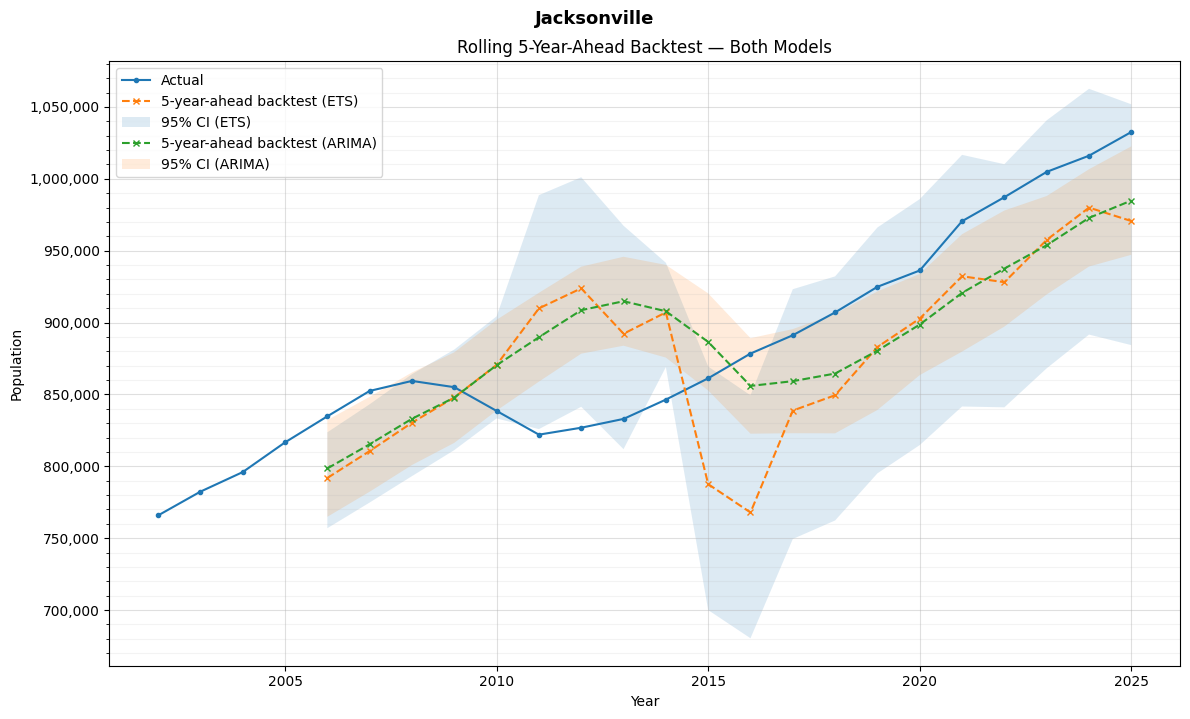

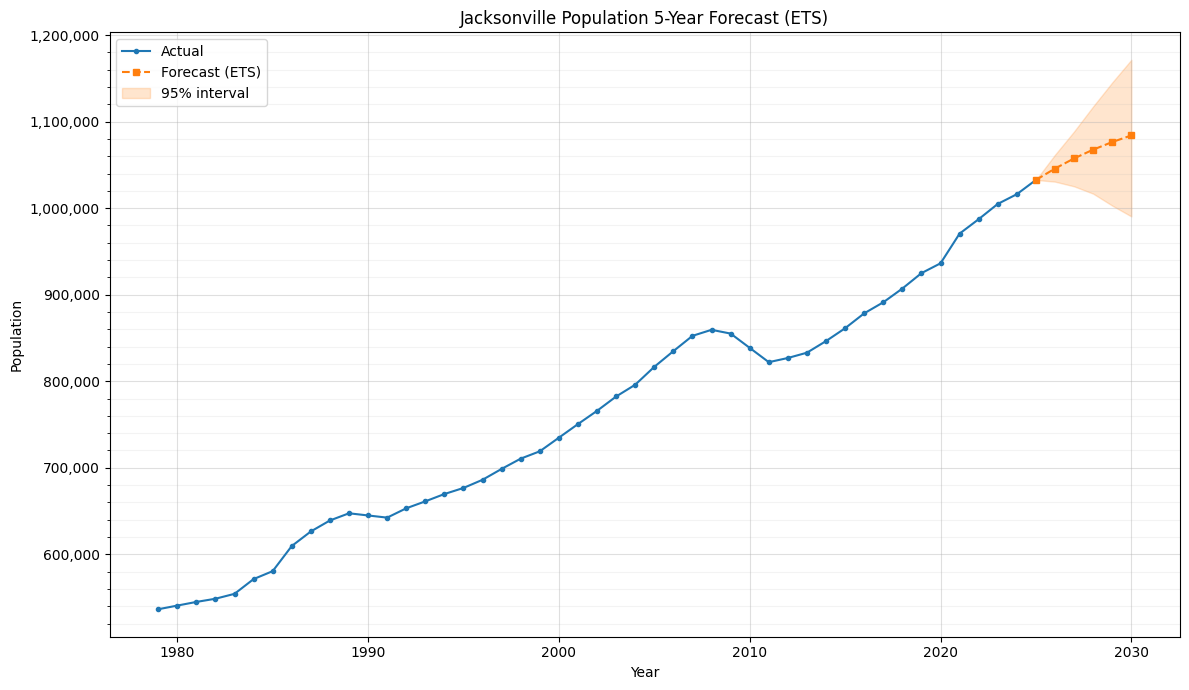

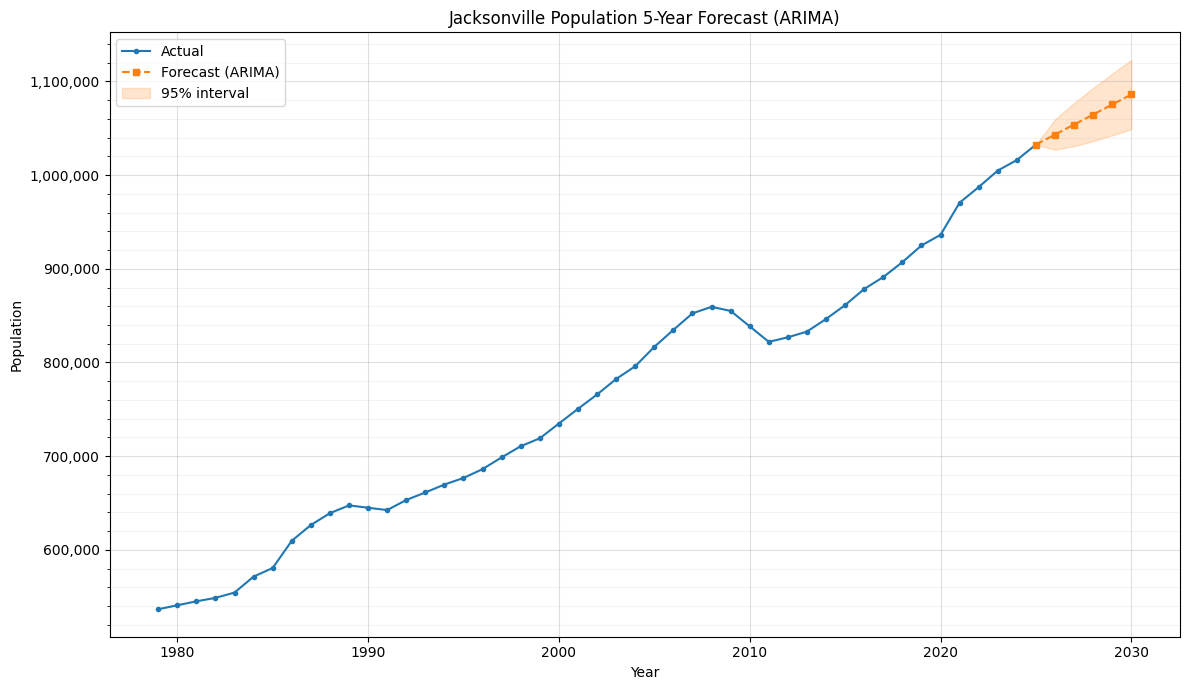

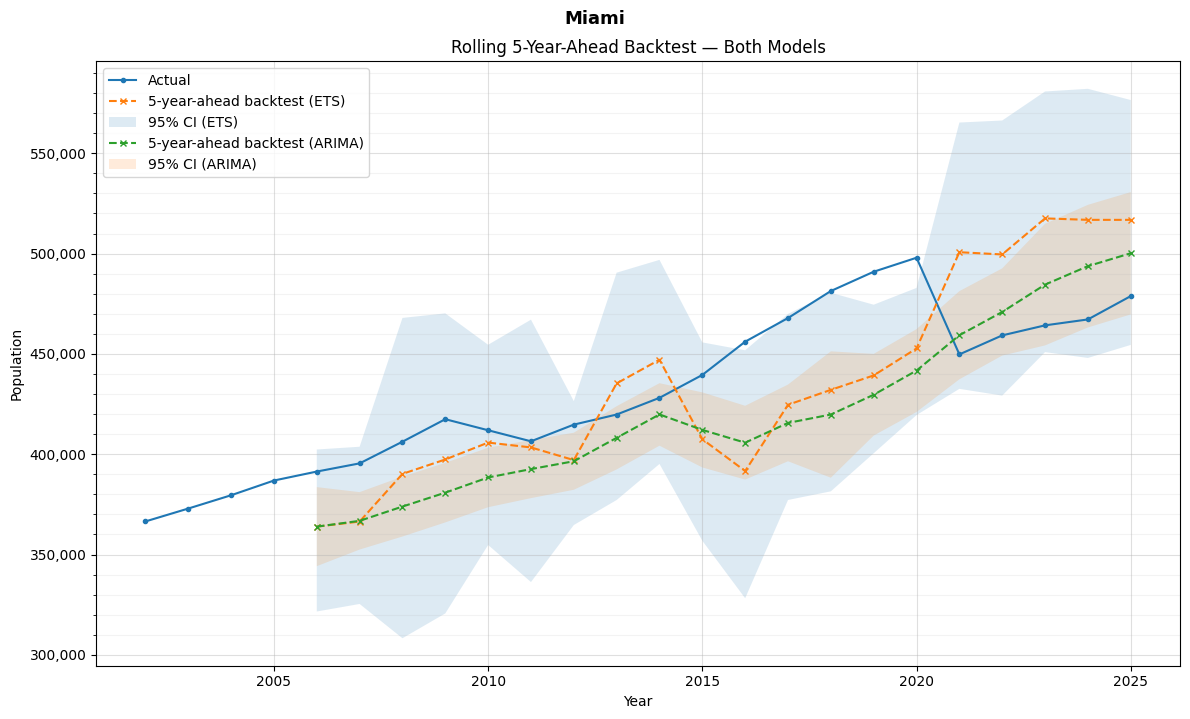

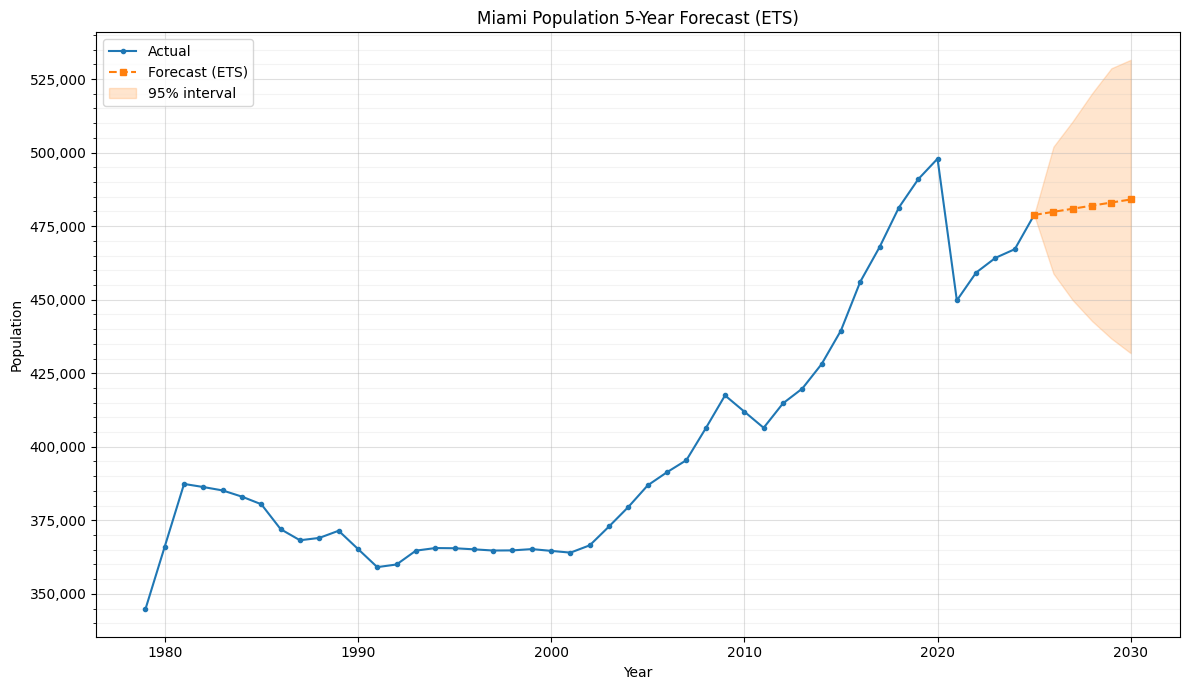

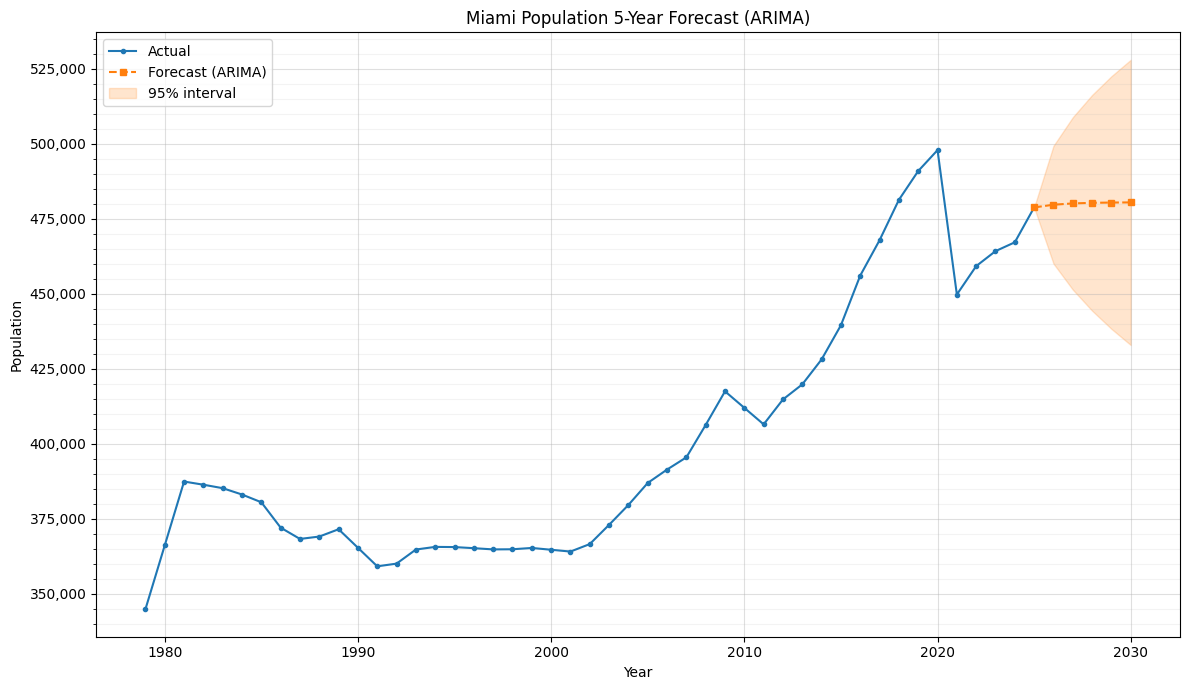

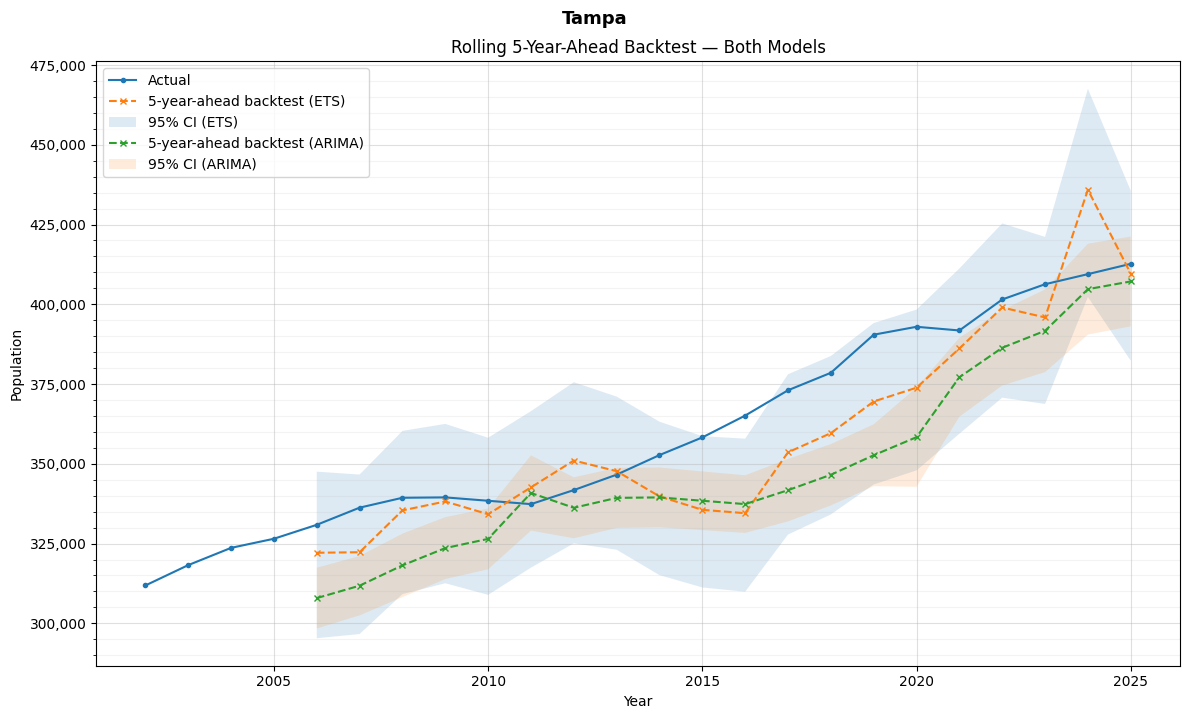

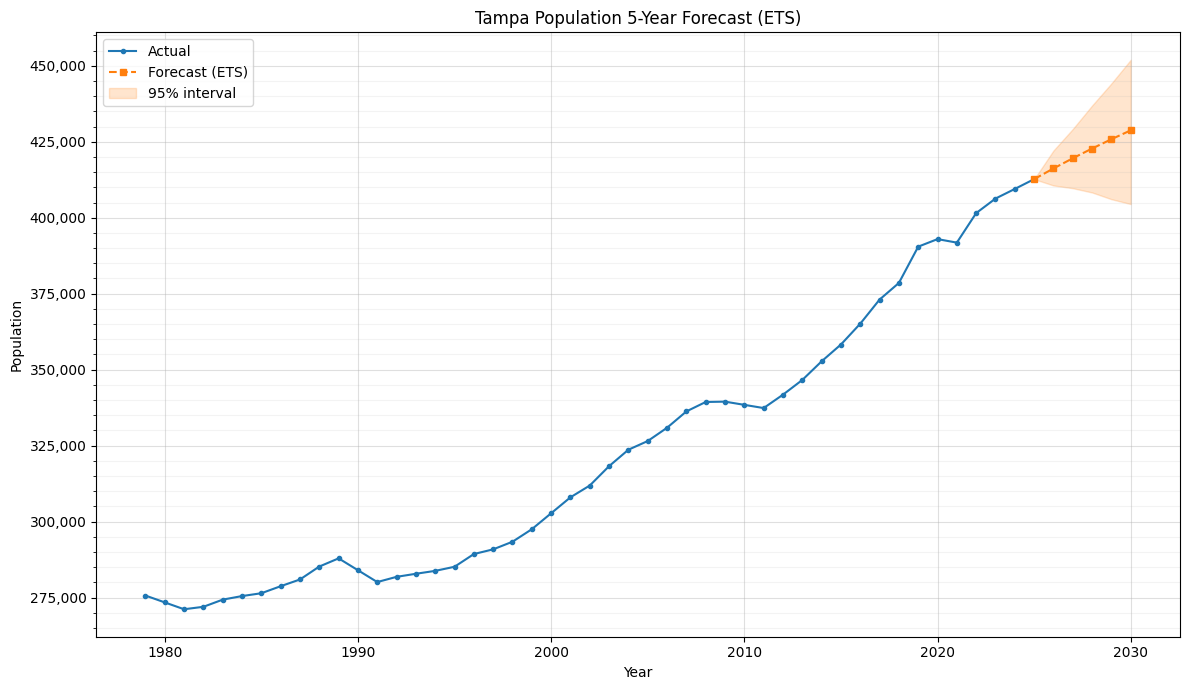

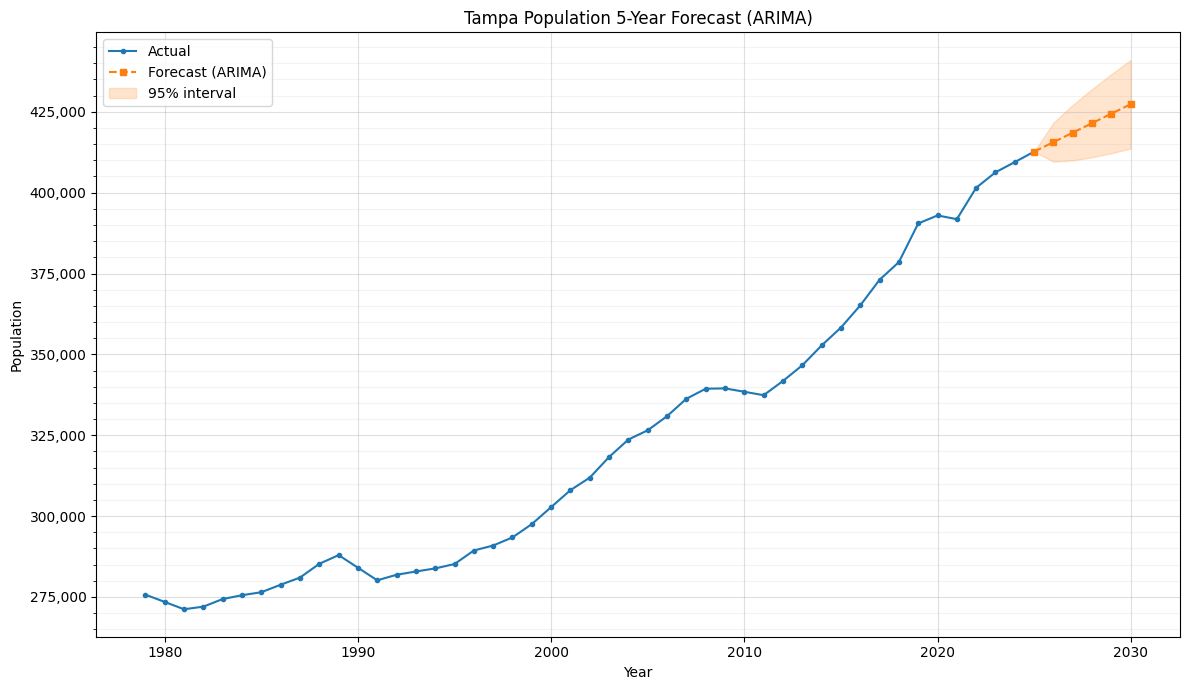

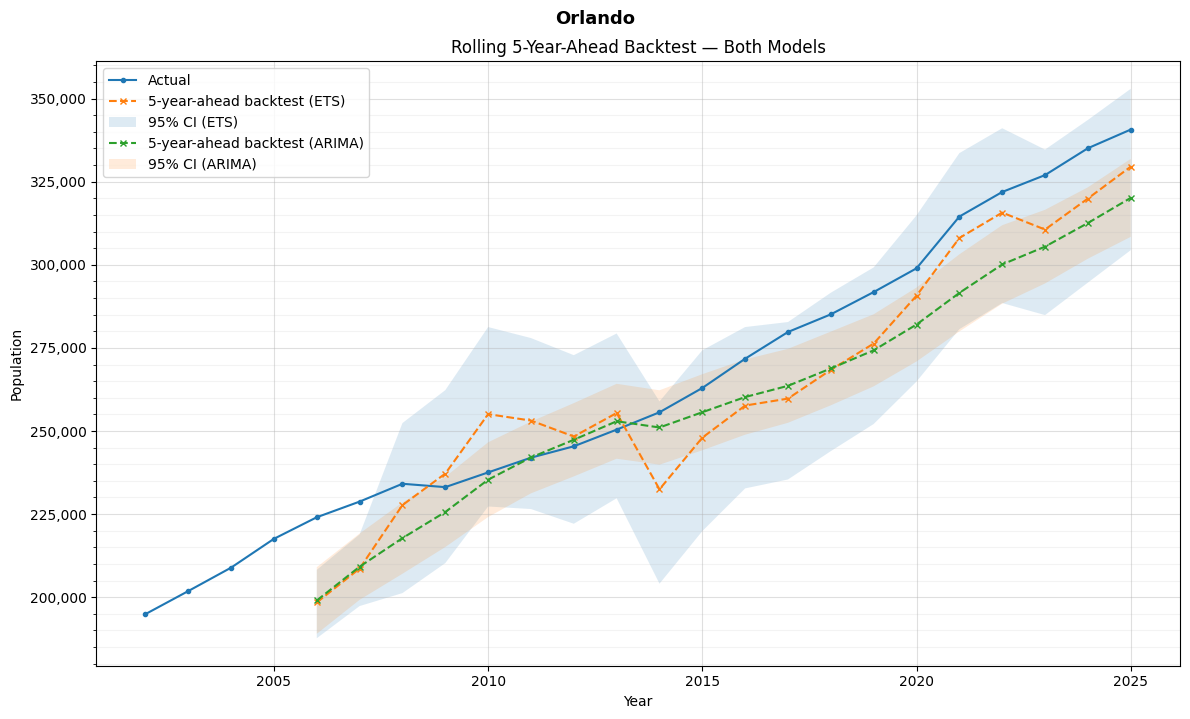

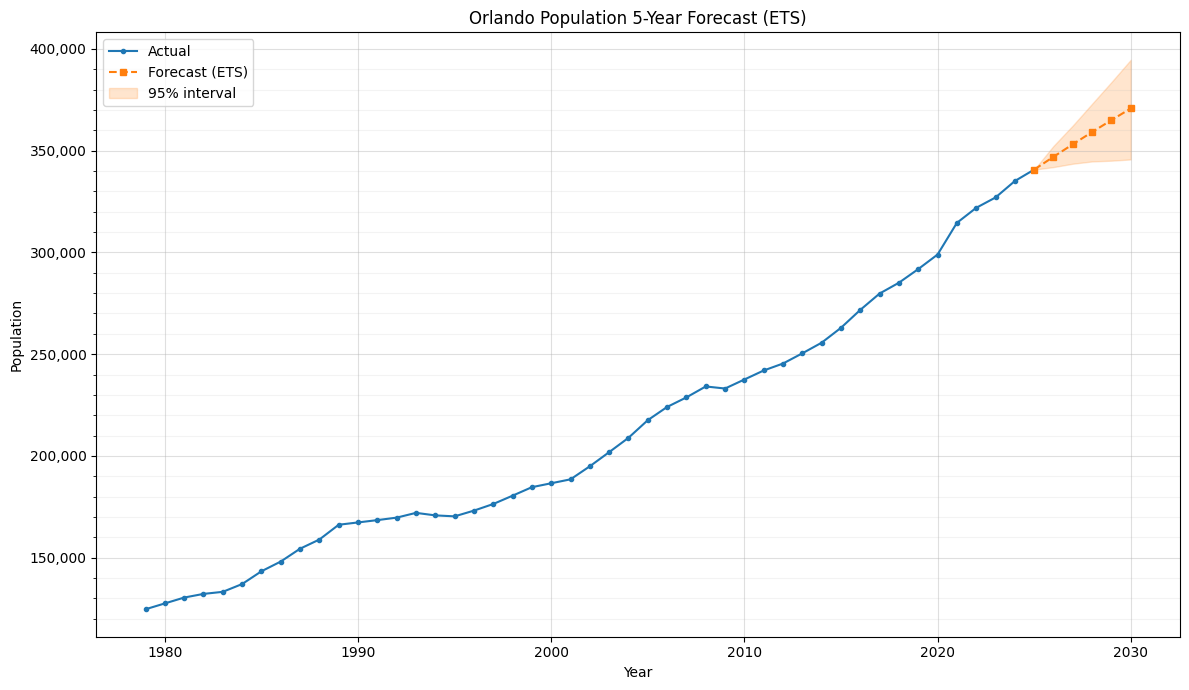

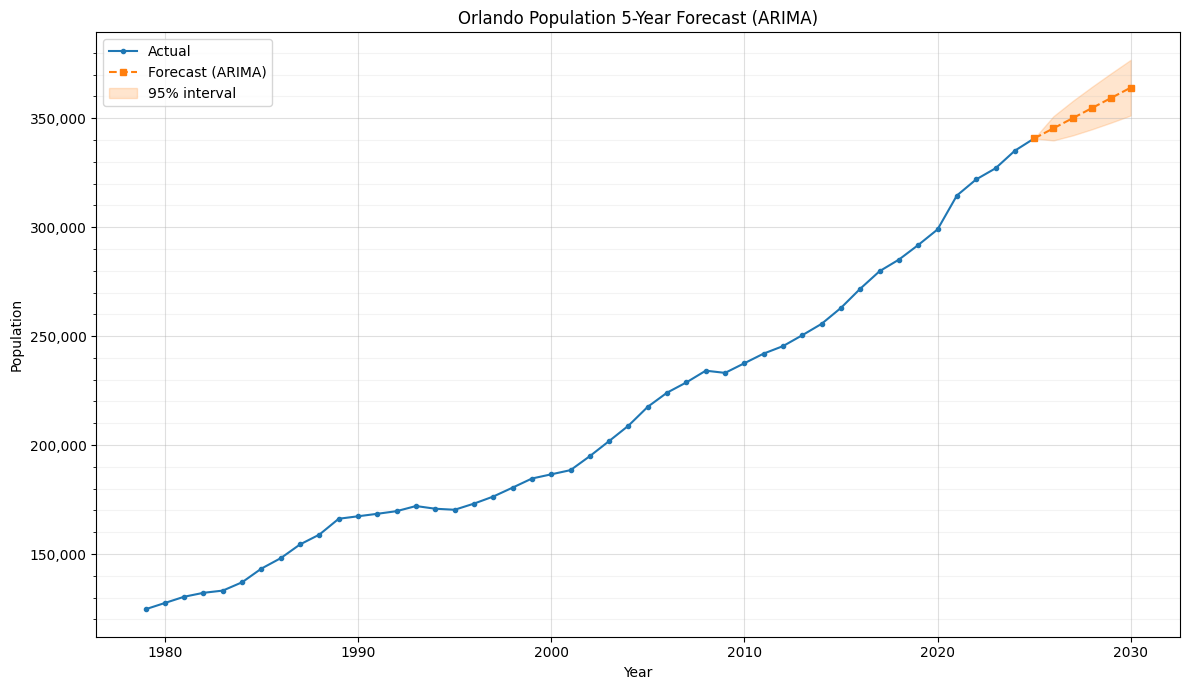

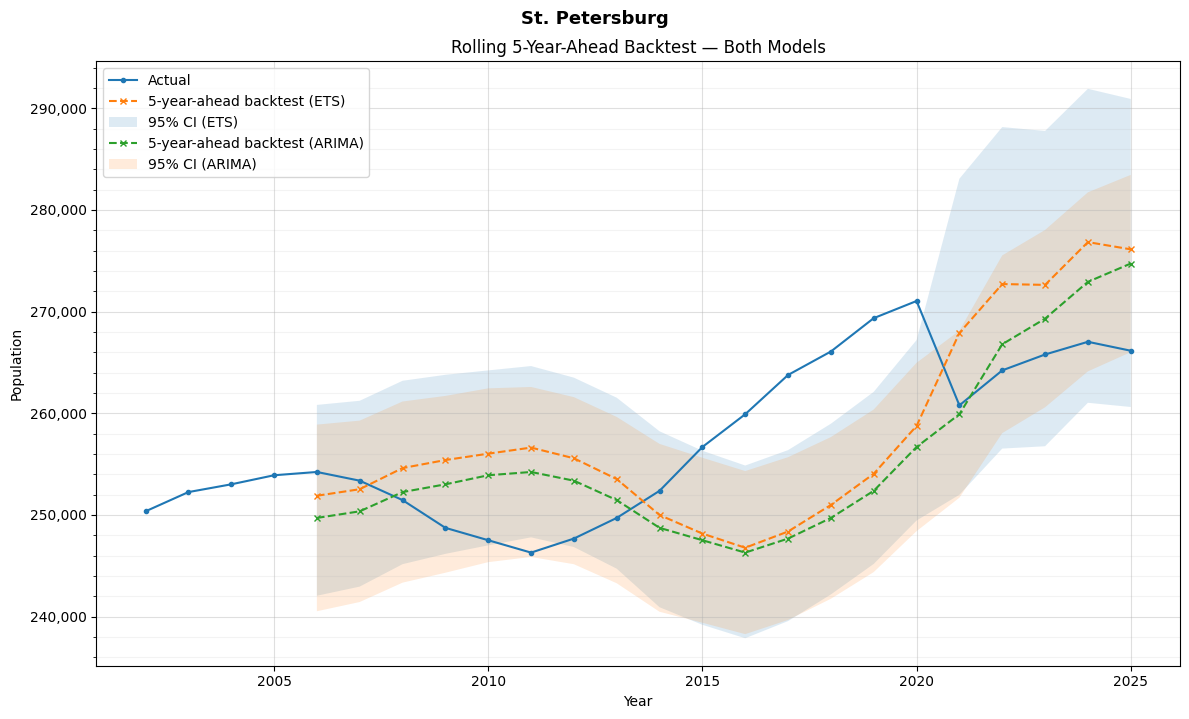

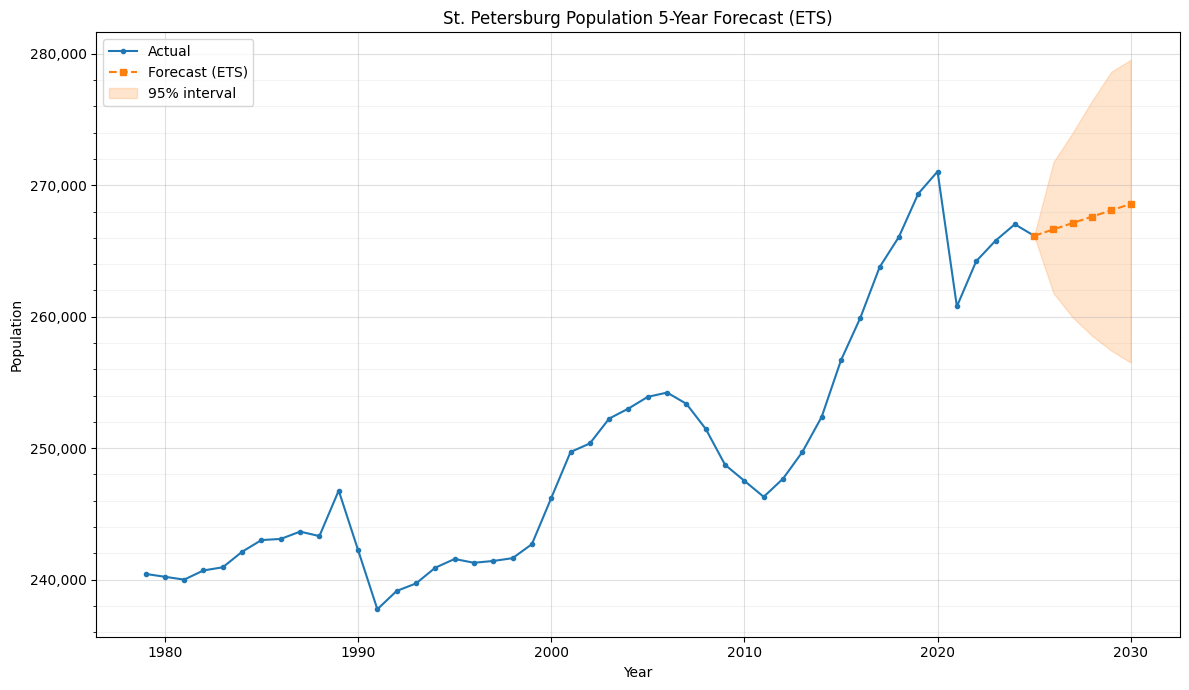

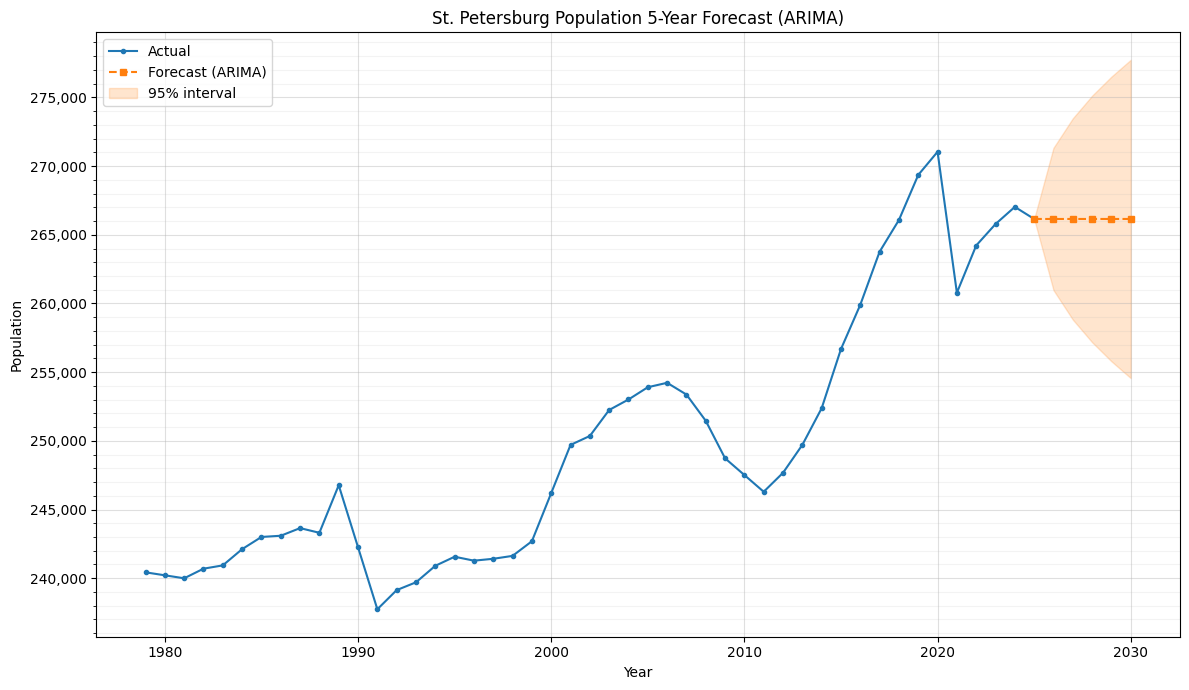

In [4]:
alpha = 0.05  # 95% confidence interval
results = []

for place_id, meta in targets.iterrows():
    yrs, pop = city_series(fl_panel, place_id)
    if len(pop) < MIN_OBS:
        print(f"{meta['city']}: skipped, only {len(pop)} years of data")
        continue
    label = clean_city_name(meta["city"])
    results.append(run_city(label, yrs, pop, alpha=alpha, show=True))

plt.show()

## 4. Summary table

The same table `population_forecast.py` saves to
`outputs/population_forecast.csv`, rebuilt from scratch here.

In [5]:
import pandas as pd

pd.DataFrame(results)

,city,last_year,last_population,best_model,mae_ets,rmse_ets,mae_arima,rmse_arima,2030_forecast,2030_lower,2030_upper,pct_change_5y
0,Jacksonville,2025,1032601,arima,53505,58633,43878,47585,1086110,1049108,1123112,5.18
1,Miami,2025,478799,arima,33602,37668,29954,34474,480476,432903,528050,0.35
2,Tampa,2025,412684,ets,12026,14890,18196,20907,428742,404492,451949,3.89
3,Orlando,2025,340681,ets,13042,14548,13740,15921,370731,345681,394638,8.82
4,St. Petersburg,2025,266153,arima,8397,9443,7303,9001,266153,254566,277740,-0.00


## Using other cities

Nothing in `run_city` is specific to these five cities. Edit the registry in
`sources/cities.py`, or call `run_city` directly on any `(years, population)`
pair, for example another EDR municipality from `city_series`, or a US city
from the ACS1 loader in `../model_benchmark/core/census.py`.